In [2]:
import pandas as pd

titanic_df = pd.read_csv("Titanic_data.csv")

In [3]:
titanic_df.shape # rows and columns

(891, 12)

In [4]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
titanic_df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

* Average age is 27, which suggest most of the passengers are young people
* Mean and medium are nearly smae 

In [7]:
titanic_df.value_counts("Survived")

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
titanic_df.value_counts("Survived", normalize = True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [9]:
titanic_df[titanic_df.Sex == "male"].value_counts("Survived")

Survived
0    468
1    109
Name: count, dtype: int64

In [10]:
titanic_df[titanic_df.Sex == "female"].value_counts("Survived")

Survived
1    233
0     81
Name: count, dtype: int64

In [11]:
titanic_df.value_counts(['Sex', 'Survived'], normalize = True)

Sex     Survived
male    0           0.525253
female  1           0.261504
male    1           0.122334
female  0           0.090909
Name: proportion, dtype: float64

**Dataframe.unique()**

In [12]:
titanic_df.Embarked.unique()

array(['S', 'C', 'Q', nan], dtype=object)

**Dataframe.nunique()**

In [13]:
# counting Null value

titanic_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
titanic_df.notna().sum()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [15]:
## Why nearly 65% of highest paying customer are female in 1912 ?


In [16]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
female = titanic_df[titanic_df['Sex'] == 'female']


In [18]:
male = titanic_df[titanic_df['Sex']== 'male']

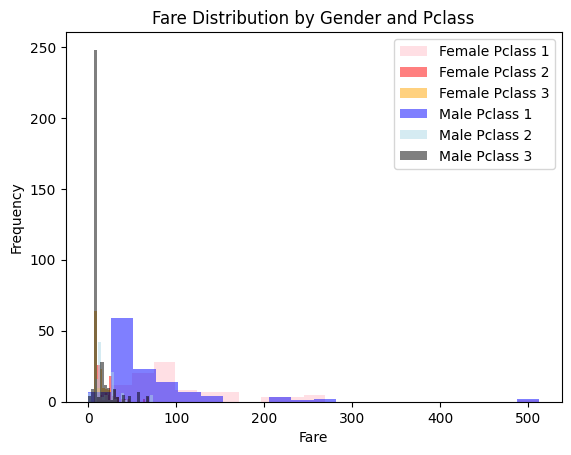

In [19]:
# Plotting fare distribution for females by Pclass
ax = female[female['Pclass'] == 1]['Fare'].plot(kind='hist', bins=20, alpha=0.5, label='Female Pclass 1', color='pink')
female[female['Pclass'] == 2]['Fare'].plot(kind='hist', bins=20, alpha=0.5, label='Female Pclass 2', color='red', ax=ax)
female[female['Pclass'] == 3]['Fare'].plot(kind='hist', bins=20, alpha=0.5, label='Female Pclass 3', color='orange', ax=ax)

# Plotting fare distribution for males by Pclass
male[male['Pclass'] == 1]['Fare'].plot(kind='hist', bins=20, alpha=0.5, label='Male Pclass 1', color='blue', ax=ax)
male[male['Pclass'] == 2]['Fare'].plot(kind='hist', bins=20, alpha=0.5, label='Male Pclass 2', color='lightblue', ax=ax)
male[male['Pclass'] == 3]['Fare'].plot(kind='hist', bins=20, alpha=0.5, label='Male Pclass 3', color='black', ax=ax)

# Add title, labels, and legend
ax.set_title('Fare Distribution by Gender and Pclass')
ax.set_xlabel('Fare')
ax.set_ylabel('Frequency')
ax.legend()

# Display the plot (automatically handled in most environments)


In [20]:
# Filter for male passengers in Pclass 3
male_class_3 = titanic_df[(titanic_df['Sex'] == 'male') & (titanic_df['Pclass'] == 3)]

# Find the population (count) of male passengers in Pclass 3
male_class_3_population = len(male_class_3)

print(f"Population of male passengers in Pclass 3: {male_class_3_population}")


Population of male passengers in Pclass 3: 347


In [21]:
print(f'Female Fare: {female['Fare'].sum()}')
print(f'Male Fare: {male['Fare'].sum()}')

print(f"Male population: {len(male)}")
print(f"Female population: {len(female)}")

Female Fare: 13966.6628
Male Fare: 14727.286500000002
Male population: 577
Female population: 314


**To determine if female passengers are 65% higher paying customers than male passengers, 
you need to calculate the average fare for both male and 
female passengers and then compare the percentage difference.**

In [22]:
Female_average_fare = female['Fare'].sum()/len(female)
print("Female average Fare: ",round(Female_average_fare, 2)) # Female average fare is 44.48

male_average_fare = male['Fare'].sum()/len(male)
print("male average Fare: ",round(male_average_fare, 2)) # Male average fare is 25.52


percentage_difference = (Female_average_fare-male_average_fare/male_average_fare)
print(percentage_difference)

Female average Fare:  44.48
male average Fare:  25.52
43.47981783439491


In [23]:
#Finding the percentage difference between the average fare for females and males.

percentage_difference = ((Female_average_fare-male_average_fare)/male_average_fare)*100
print(round(percentage_difference,2)) # 

74.27


**This means females pay 74.27% more on average compared to males.**

In [24]:
# Count of males and females in each class
class_distribution = titanic_df.groupby(['Sex', 'Pclass']).size()
print(class_distribution)


Sex     Pclass
female  1          94
        2          76
        3         144
male    1         122
        2         108
        3         347
dtype: int64


In [29]:
# Survival rate comparison by gender and class
survival_rate = titanic_df[['Survived','Pclass','Sex']].groupby(by = 'Sex').mean()
print(survival_rate)


        Survived    Pclass
Sex                       
female  0.742038  2.159236
male    0.188908  2.389948


In [97]:
# Checking cabin preference by gender
cabin_distribution = titanic_df.groupby(['Sex', 'Cabin']).size()
print(cabin_distribution)


Sex     Cabin
female  A16      1
        B18      2
        B20      1
        B22      1
        B28      2
                ..
male    F G73    2
        F2       3
        F38      1
        F4       1
        T        1
Length: 171, dtype: int64


In [98]:
# Count the number of female passengers in each cabin
female_cabin_counts = female['Cabin'].value_counts().sum()
male_cabin_counts = male['Cabin'].value_counts().sum()
# Display the result
print(female_cabin_counts)
print(male_cabin_counts)

97
107


- Out of 314 females 97 has booked there own cabin
- Out of 577 males only 107 has booked cabin

In [31]:
# Compare fare by age and gender
age_fare_relation = titanic_df[['Sex', 'Age','Fare']].groupby('Sex').mean()
print(age_fare_relation)


              Age       Fare
Sex                         
female  27.915709  44.479818
male    30.726645  25.523893


- The average age of female is 27 and Average fare is 44 dollars.
- The average age of male is 30 and Average fare is 25 dollars.

**So Female pays 19 dollar more than male in average**

In [79]:

# Check if women are traveling in larger family groups
family_size = titanic_df.groupby(['Sex'])[['SibSp', 'Parch']].mean()  # SibSp (siblings/spouses), Parch (parents/children)
print(family_size)


           SibSp     Parch
Sex                       
female  0.694268  0.649682
male    0.429809  0.235702


- Women had higher average values for both siblings/spouses and parents/children than men, indicating that female passengers were more likely to be part of larger family groups on the Titanic.

- Men had lower averages, suggesting that they were more frequently traveling alone or with fewer family members.


In [35]:
# Check fare distribution by embarkation location and gender
embark_fare = titanic_df[['Sex', 'Embarked','Fare']].groupby(['Sex','Embarked']).mean()
print(embark_fare)


                      Fare
Sex    Embarked           
female C         75.169805
       Q         12.634958
       S         38.740929
male   C         48.262109
       Q         13.838922
       S         21.711996


- female fare was 27 dollar higher in cherbourg and 17 dollars from Southampton
- Cherbourg:

Female passengers paid significantly more than male passengers on average (75.17 vs. 48.26).
This might indicate that the females boarding from Cherbourg were more likely to be from wealthier backgrounds or traveling in higher classes.

- Queenstown:

The average fare for both genders is relatively low, with females at 12.63 and males at 13.84.
This might indicate that the majority of passengers from Queenstown were likely in lower classes.

-Southampton:

Female passengers paid an average fare of 38.74, while males paid 21.71.
This suggests a trend similar to Cherbourg, where females were paying higher fares, possibly reflecting class differences among passengers.

In [46]:
embark = titanic_df[['Sex', 'Embarked']].groupby(['Sex','Embarked']).size()
print(embark)

Sex     Embarked
female  C            73
        Q            36
        S           203
male    C            95
        Q            41
        S           441
dtype: int64


In [55]:
average_age_pclass_1 = titanic_df[titanic_df['Pclass'] == 1]['Age'].mean()

print("Average Age of Passengers in Pclass 1:", round(average_age_pclass_1, 2))

Average Age of Passengers in Pclass 1: 38.23


In [61]:
family_size = titanic_df.groupby(['Sex','Embarked'])[['SibSp', 'Parch',]].mean()
family_size

SibSp     Parch
Sex    Embarked                    
female C         0.547945  0.493151
       Q         0.222222  0.222222
       S         0.837438  0.788177
male   C         0.263158  0.263158
       Q         0.609756  0.121951
       S         0.448980  0.240363

## Insights:
#### Female Passengers:

- `Cherbourg (C)`:

SibSp: 0.55 (approximately)
Parch: 0.49 (approximately)
Insight: Female passengers from Cherbourg had a relatively high average number of siblings/spouses and parents/children. This might suggest that many women traveled with family members, indicating a social norm of family travel.

- `Queenstown (Q)`:

SibSp: 0.22 (approximately)
Parch: 0.22 (approximately)

Insight: The average number of siblings/spouses and parents/children is lower here, which may indicate that fewer women traveled with family from this port, possibly reflecting a demographic difference.

- `Southampton (S)`:

SibSp: 0.84 (approximately)
Parch: 0.79 (approximately)
Insight: Female passengers from Southampton had the highest averages for both categories, suggesting that many traveled with significant family support.

### Male Passengers:

- `Cherbourg (C)`:

SibSp: 0.26 (approximately)
Parch: 0.26 (approximately)
Insight: Male passengers from Cherbourg had a lower average of siblings/spouses and parents/children than their female counterparts. This may reflect social norms regarding men traveling alone for work or other reasons.

- `Queenstown (Q)`:

SibSp: 0.61 (approximately)
Parch: 0.12 (approximately)
Insight: Here, males had a high average of siblings/spouses but a low average of parents/children. This could indicate that many men traveled with siblings or spouses but did not bring children or parents, possibly due to socio-economic factors or travel constraints.

- `Southampton (S)`:

SibSp: 0.45 (approximately)
Parch: 0.24 (approximately)
Insight: Male passengers from Southampton had moderate averages in both categories, indicating that some men traveled with family, but not as prominently as females from the same port.


## Conclusion: 

- In average females were traveling with families more compare to male.
- Fare of females are 74.29% higher than men.
